In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow_docs.vis import embed
import imutils
import numpy as np
import cv2

c:\Users\reziv\OneDrive\Documents\GitHub\SwimVisionProject\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
c:\Users\reziv\OneDrive\Documents\GitHub\SwimVisionProject\.venv\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [ ]:


# Import matplotlib libraries
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.patches as patches

import kagglehub

# Download latest version


# Some modules to display an animation using imageio.
#import imageio
#from IPython.display import HTML, display

c:\Users\reziv\OneDrive\Documents\GitHub\SwimVisionProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model_name = "movenet_thunder"

if "tflite" in model_name:
  if "movenet_lightning_f16" in model_name:
    !wget -q -O model.tflite https://tfhub.dev/google/lite-model/movenet/singlepose/lightning/tflite/float16/4?lite-format=tflite
    input_size = 192
  elif "movenet_thunder_f16" in model_name:
    !wget -q -O model.tflite https://tfhub.dev/google/lite-model/movenet/singlepose/thunder/tflite/float16/4?lite-format=tflite
    input_size = 256
  elif "movenet_lightning_int8" in model_name:
    !wget -q -O model.tflite https://tfhub.dev/google/lite-model/movenet/singlepose/lightning/tflite/int8/4?lite-format=tflite
    input_size = 192
  elif "movenet_thunder_int8" in model_name:
    !wget -q -O model.tflite https://tfhub.dev/google/lite-model/movenet/singlepose/thunder/tflite/int8/4?lite-format=tflite
    input_size = 256
  else:
    raise ValueError("Unsupported model name: %s" % model_name)

  # Initialize the TFLite interpreter
  interpreter = tf.lite.Interpreter(model_path="model.tflite")
  interpreter.allocate_tensors()

  def movenet(input_image):
    """Runs detection on an input image.

    Args:
      input_image: A [1, height, width, 3] tensor represents the input image
        pixels. Note that the height/width should already be resized and match the
        expected input resolution of the model before passing into this function.

    Returns:
      A [1, 1, 17, 3] float numpy array representing the predicted keypoint
      coordinates and scores.
    """
    # TF Lite format expects tensor type of uint8.
    input_image = tf.cast(input_image, dtype=tf.uint8)
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    interpreter.set_tensor(input_details[0]['index'], input_image.numpy())
    # Invoke inference.
    interpreter.invoke()
    # Get the model prediction.
    keypoints_with_scores = interpreter.get_tensor(output_details[0]['index'])
    return keypoints_with_scores

else:
  if "movenet_lightning" in model_name:
    module = hub.load("https://tfhub.dev/google/movenet/singlepose/lightning/4")
    input_size = 192
  elif "movenet_thunder" in model_name:
    module = hub.load("https://tfhub.dev/google/movenet/singlepose/thunder/4")
    input_size = 256
  else:
    raise ValueError("Unsupported model name: %s" % model_name)

  def movenet(input_image):
    """Runs detection on an input image.

    Args:
      input_image: A [1, height, width, 3] tensor represents the input image
        pixels. Note that the height/width should already be resized and match the
        expected input resolution of the model before passing into this function.

    Returns:
      A [1, 1, 17, 3] float numpy array representing the predicted keypoint
      coordinates and scores.
    """
    model = module.signatures['serving_default']

    # SavedModel format expects tensor type of int32.
    input_image = tf.cast(input_image, dtype=tf.int32)
    # Run model inference.
    outputs = model(input_image)
    # Output is a [1, 1, 17, 3] tensor.
    keypoints_with_scores = outputs['output_0'].numpy()
    return keypoints_with_scores

In [ ]:
videoPath = '../Data/LG.mp4'
video = tf.io.read_file(videoPath)




In [ ]:
def draw_keypoints(frame, keypoints, confidence_threshold):
    y, x, c = frame.shape
    shaped = np.squeeze(np.multiply(keypoints, [y,x,1]))
    

    for kp in shaped[5:]:
        ky, kx, kp_conf = kp
        if kp_conf > confidence_threshold:
            cv2.circle(frame, (int(kx), int(ky)), 4, (0, 255, 0), -1)

In [ ]:
# cap = cv2.VideoCapture(videoPath)
cap = cv2.VideoCapture(videoPath)
while cap.isOpened():
    ret, frame = cap.read()
    #frame = cv2.cvtColor(frame, cv2.COLOR_LUV2BGR)
    # Reshape Image
    frame = imutils.resize(frame, width=400)
    img = frame.copy()
    
    img = tf.image.resize_with_pad(np.expand_dims(img, axis=0), input_size, input_size)
    input_image = tf.cast(img, dtype=tf.float32)

    # Setup input and output
    # input_details = interpreter.get_input_details()
    # output_details = interpreter.get_output_details()

    # interpreter.set_tensor(input_details[0]['index'], np.array(input_image))
    # interpreter.invoke()
    # keypoints_with_scores = interpreter.get_tensor(output_details[0]['index'])
    # print(keypoints_with_scores)

    keys_with_scores = movenet(input_image)
    #print(keys_with_scores)

    #Make predictions

    draw_keypoints(frame, keys_with_scores, 0.1)
    cv2.imshow("Movenet Lightning", frame)
    if cv2.waitKey(25) & 0xFF==ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
right_eye_coords = np.array(keys_with_scores[0][0][2][:2]*[1920, 1080]).astype(int)
print(right_eye_coords[0])
print(right_eye_coords[1])

417
351


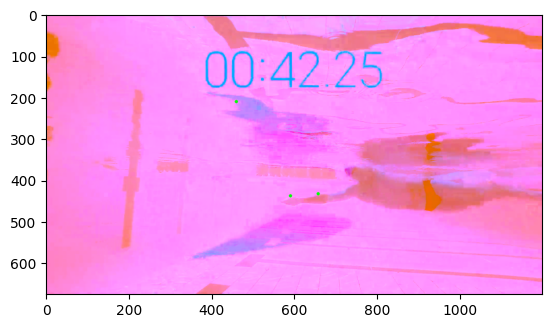

In [ ]:
plt.imshow(frame)